In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("ufc-master.csv")


In [3]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6528 entries, 0 to 6527
Data columns (total 118 columns):
 #    Column                       Non-Null Count  Dtype  
---   ------                       --------------  -----  
 0    RedFighter                   6528 non-null   object 
 1    BlueFighter                  6528 non-null   object 
 2    RedOdds                      6301 non-null   float64
 3    BlueOdds                     6302 non-null   float64
 4    RedExpectedValue             6301 non-null   float64
 5    BlueExpectedValue            6302 non-null   float64
 6    Date                         6528 non-null   object 
 7    Location                     6528 non-null   object 
 8    Country                      6528 non-null   object 
 9    Winner                       6528 non-null   object 
 10   TitleBout                    6528 non-null   bool   
 11   WeightClass                  6528 non-null   object 
 12   Gender                       6528 non-null   object 
 13   N

In [4]:
df.head(5)

,RedFighter,BlueFighter,RedOdds,BlueOdds,RedExpectedValue,BlueExpectedValue,Date,Location,Country,Winner,...,FinishDetails,FinishRound,FinishRoundTime,TotalFightTimeSecs,RedDecOdds,BlueDecOdds,RSubOdds,BSubOdds,RKOOdds,BKOOdds
0,Alexandre Pantoja,Kai Asakura,-250.0,215.0,40.0000,215.0,2024-12-07,"Las Vegas, Nevada, USA",USA,Red,...,Rear Naked Choke,2.0,2:05,425.0,300.0,800.0,150.0,2500.0,400.0,350.0
1,Shavkat Rakhmonov,Ian Machado Garry,-210.0,295.0,47.6190,295.0,2024-12-07,"Las Vegas, Nevada, USA",USA,Red,...,NaN,5.0,5:00,1500.0,250.0,650.0,180.0,3000.0,240.0,700.0
2,Ciryl Gane,Alexander Volkov,-380.0,300.0,26.3158,300.0,2024-12-07,"Las Vegas, Nevada, USA",USA,Red,...,NaN,3.0,5:00,900.0,-160.0,450.0,1100.0,3000.0,350.0,1100.0
3,Bryce Mitchell,Kron Gracie,-950.0,625.0,10.5263,625.0,2024-12-07,"Las Vegas, Nevada, USA",USA,Red,...,Elbows,3.0,0:39,639.0,-200.0,1100.0,380.0,1400.0,500.0,4000.0
4,Nate Landwehr,Dooho Choi,-130.0,110.0,76.9231,110.0,2024-12-07,"Las Vegas, Nevada, USA",USA,Blue,...,Elbows,3.0,3:21,801.0,275.0,550.0,500.0,700.0,300.0,250.0


In [5]:
keep_cols = ['RedFighter', 'BlueFighter', 'Winner', 'Date', 'WeightClass',
    'RedOdds', 'BlueOdds',
    'AgeDif', 'ReachDif', 'HeightDif',
    'SigStrDif', 'AvgTDDif', 'AvgSubAttDif',
    'WinStreakDif', 'LossDif' ]

#Lets make a copy from original dataset
df_ufc = df[keep_cols].copy()

#lets check for some problems in this new df
print(df_ufc.isnull().sum())

RedFighter        0
BlueFighter       0
Winner            0
Date              0
WeightClass       0
RedOdds         227
BlueOdds        226
AgeDif            0
ReachDif          0
HeightDif         0
SigStrDif         0
AvgTDDif          0
AvgSubAttDif      0
WinStreakDif      0
LossDif           0
dtype: int64


In [6]:
print(df_ufc.isnull().sum())

RedFighter        0
BlueFighter       0
Winner            0
Date              0
WeightClass       0
RedOdds         227
BlueOdds        226
AgeDif            0
ReachDif          0
HeightDif         0
SigStrDif         0
AvgTDDif          0
AvgSubAttDif      0
WinStreakDif      0
LossDif           0
dtype: int64


In [7]:
df_ufc.dropna(subset=['RedOdds'] ,inplace=True)
df_ufc.isnull().sum()

,0
RedFighter,0
BlueFighter,0
Winner,0
Date,0
WeightClass,0
RedOdds,0
BlueOdds,11
AgeDif,0
ReachDif,0
HeightDif,0


In [8]:
df_ufc.dropna(subset=['BlueOdds'] ,inplace=True)
df_ufc.isnull().sum()

,0
RedFighter,0
BlueFighter,0
Winner,0
Date,0
WeightClass,0
RedOdds,0
BlueOdds,0
AgeDif,0
ReachDif,0
HeightDif,0


In [9]:
df_ufc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6290 entries, 0 to 6527
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   RedFighter    6290 non-null   object 
 1   BlueFighter   6290 non-null   object 
 2   Winner        6290 non-null   object 
 3   Date          6290 non-null   object 
 4   WeightClass   6290 non-null   object 
 5   RedOdds       6290 non-null   float64
 6   BlueOdds      6290 non-null   float64
 7   AgeDif        6290 non-null   int64  
 8   ReachDif      6290 non-null   float64
 9   HeightDif     6290 non-null   float64
 10  SigStrDif     6290 non-null   float64
 11  AvgTDDif      6290 non-null   float64
 12  AvgSubAttDif  6290 non-null   float64
 13  WinStreakDif  6290 non-null   int64  
 14  LossDif       6290 non-null   int64  
dtypes: float64(7), int64(3), object(5)
memory usage: 786.2+ KB


In [10]:
df_ufc['Target']=df_ufc['Winner'].map({'Red':1,'Blue':0})
reach_win_rate = df_ufc[df_ufc['ReachDif']>0]['Target'].mean()
strike_win_rate = df_ufc[df_ufc['SigStrDif']>0]['Target'].mean()

print(f"Win rate with Reach Advantage: {reach_win_rate:.2%}")
print(f"Win rate with Striking Advantage: {strike_win_rate:.2%}")

Win rate with Reach Advantage: 56.18%
Win rate with Striking Advantage: 53.02%


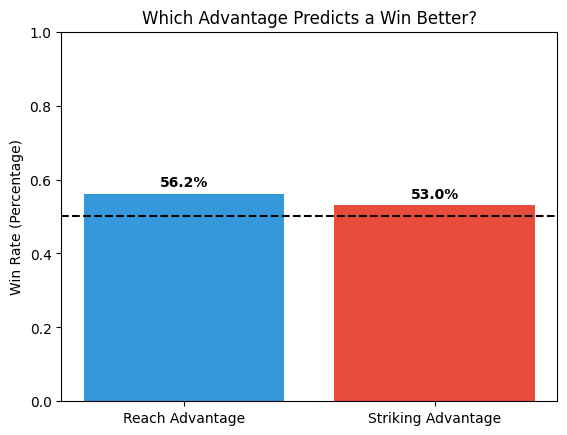

In [11]:



labels = ['Reach Advantage', 'Striking Advantage']
rates = [reach_win_rate, strike_win_rate]

plt.bar(labels, rates, color=['#3498db', '#e74c3c'])
plt.ylabel('Win Rate (Percentage)')
plt.title('Which Advantage Predicts a Win Better?')
plt.ylim(0, 1)
plt.axhline(y=0.5, color='black', linestyle='--')


for i, rate in enumerate(rates):
    plt.text(i, rate + 0.02, f'{rate:.1%}', ha='center', fontweight='bold')

plt.savefig('advantage_comparison.png')

In [12]:
big_reach = df_ufc[df_ufc['ReachDif']>5]['Target'].mean()
big_strike = df_ufc[df_ufc['SigStrDif']>5]['Target'].mean()

print(f"Big reach win rate:{big_reach:.1%}")

print(f"Big Striking win rate:{big_strike:.1%}")

Big reach win rate:55.9%
Big Striking win rate:53.9%


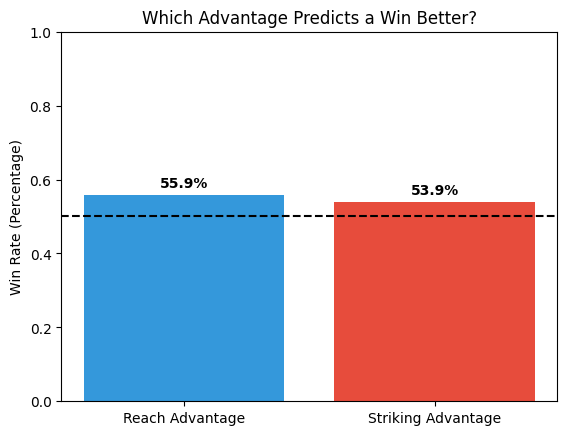

In [13]:
labels = ['Reach Advantage', 'Striking Advantage']
rates = [big_reach, big_strike]

plt.bar(labels, rates, color=['#3498db', '#e74c3c'])
plt.ylabel('Win Rate (Percentage)')
plt.title('Which Advantage Predicts a Win Better?')
plt.ylim(0, 1)
plt.axhline(y=0.5, color='black', linestyle='--')


for i, rate in enumerate(rates):
    plt.text(i, rate + 0.02, f'{rate:.1%}', ha='center', fontweight='bold')

plt.savefig('advantage_comparison.png')

In [14]:
# Hint: We can filter for both at once
both_adv = df_ufc[(df_ufc['ReachDif'] > 0) & (df_ufc['SigStrDif'] > 0)]['Target'].mean()
print(f"Win rate with BOTH advantages: {both_adv:.1%}")

Win rate with BOTH advantages: 50.8%


In [15]:
fav_win_rate = df_ufc[df_ufc['RedOdds']<-300]['Target'].mean()
print(f"Win rate for Heavy Favorites (-300 or lower): {fav_win_rate:.1%}")

Win rate for Heavy Favorites (-300 or lower): 84.2%


In [16]:
# Filtering for: Favorite AND significantly older
age_trap = df_ufc[(df_ufc['RedOdds'] < -150) & (df_ufc['AgeDif'] > 5)]['Target'].mean()

print(f"Win rate for older favorites: {age_trap:.1%}")

Win rate for older favorites: 74.3%


In [17]:
# Underdogs (Odds > 100) with a better Win Streak (WinStreakDif > 0)
streak_underdog = df_ufc[(df_ufc['RedOdds'] > 100) & (df_ufc['WinStreakDif'] > 0)]['Target'].mean()

print(f"Win rate for 'Hot' Underdogs: {streak_underdog:.1%}")

Win rate for 'Hot' Underdogs: 34.3%


In [18]:
# This shows the win rate of the Favorite (-150 or lower) per Weight Class
weight_predictability = df_ufc[df_ufc['RedOdds'] < -150].groupby('WeightClass')['Target'].mean().sort_values(ascending=False)
print(weight_predictability)

WeightClass
Women's Featherweight    0.823529
Catch Weight             0.785714
Flyweight                0.784431
Bantamweight             0.771605
Lightweight              0.744094
Heavyweight              0.740088
Welterweight             0.735683
Featherweight            0.715847
Women's Strawweight      0.715232
Light Heavyweight        0.710744
Middleweight             0.708791
Women's Flyweight        0.700000
Women's Bantamweight     0.660194
Name: Target, dtype: float64


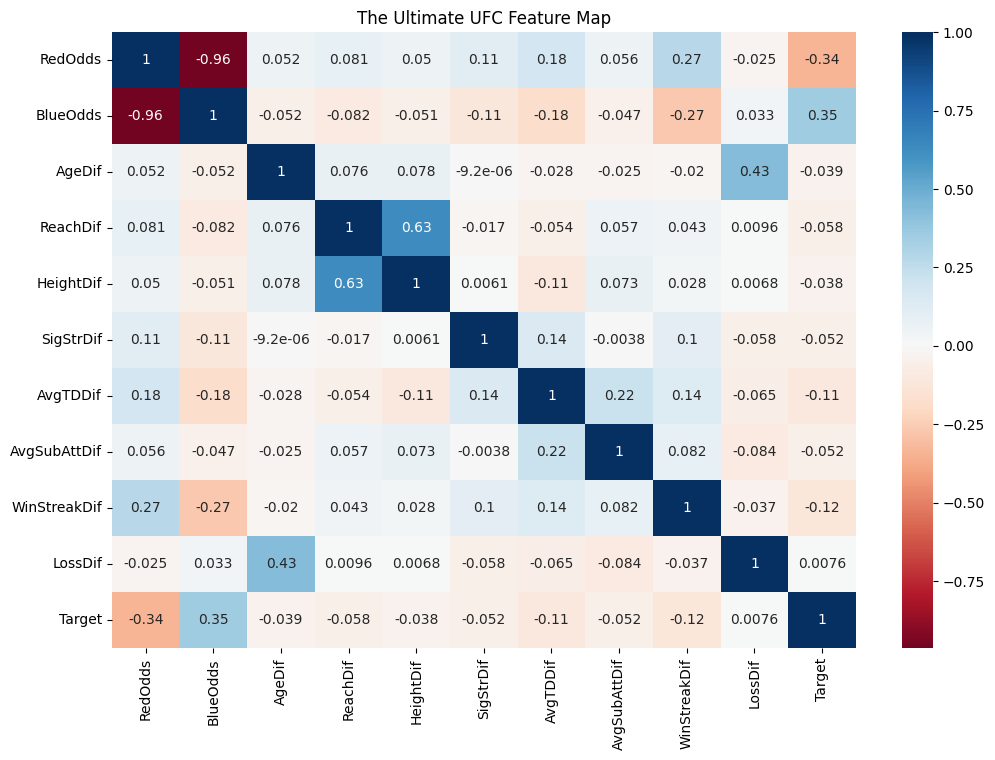

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
# We only correlate the numeric columns
corr = df_ufc.select_dtypes(include=['float64', 'int64']).corr()

sns.heatmap(corr, annot=True, cmap='RdBu', center=0)
plt.title("The Ultimate UFC Feature Map")
plt.show()